In [ ]:
import sqlite3
import pandas as pd
import os
import sys
import subprocess
import kagglehub
import pyarrow.parquet as pq
import fastparquet
import duckdb
import matplotlib.pyplot as plt

# Connect to the DuckDB database
conn = duckdb.connect("Data/nba.duckdb")

# NBA dataset from Kaggle
# nba_path = "https://www.kaggle.com/datasets/eoinamoore/historical-nba-data-and-player-box-scores/data"
# dataset_path = kagglehub.dataset_download("eoinamoore/historical-nba-data-and-player-box-scores")

c:\Users\Mark Rozenberg\Nba\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
os.listdir(dataset_path)

### Players table ingestion

In [15]:
# Read the Players CSV file
players_df = pd.read_csv(os.path.join(dataset_path, "Players.csv"))
conn.register("players_df_view", players_df)

# Ingest the data into the players table
conn.execute("""
    CREATE OR REPLACE TABLE players AS
    SELECT *
    FROM players_df_view
"""
)
conn.unregister("players_df_view")

conn.commit()

print(f"Successfully ingested {len(players_df)} records into the players table.")
print(f"\nColumns: {players_df.columns.tolist()}")

Successfully ingested 6691 records into the players table.

Columns: ['personId', 'firstName', 'lastName', 'birthDate', 'school', 'country', 'heightInches', 'bodyWeightLbs', 'guard', 'forward', 'center', 'draftYear', 'draftRound', 'draftNumber']


In [2]:
pd.read_sql_query("SELECT * FROM players LIMIT 5", conn).dtypes

C:\Users\Mark Rozenberg\AppData\Local\Temp\ipykernel_16688\3136451465.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query("SELECT * FROM players LIMIT 5", conn).dtypes


personId           int64
firstName            str
lastName             str
birthDate         object
school               str
country              str
heightInches     float64
bodyWeightLbs    float64
guard                str
forward              str
center               str
draftYear        float64
draftRound       float64
draftNumber      float64
dtype: object

In [3]:
# Convert guard/forward/center columns in players table to INTEGER
conn.execute("""
    ALTER TABLE players
    ALTER COLUMN guard TYPE INTEGER USING TRY_CAST(guard AS INTEGER)
""")
conn.execute("""
    ALTER TABLE players
    ALTER COLUMN "forward" TYPE INTEGER USING TRY_CAST("forward" AS INTEGER)
""")
conn.execute("""
    ALTER TABLE players
    ALTER COLUMN center TYPE INTEGER USING TRY_CAST(center AS INTEGER)
""")

conn.commit()

# Quick check
print(pd.read_sql_query("SELECT guard, forward, center FROM players LIMIT 5", conn).dtypes)

guard      float64
forward    float64
center     float64
dtype: object


C:\Users\Mark Rozenberg\AppData\Local\Temp\ipykernel_16688\1062729765.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql_query("SELECT guard, forward, center FROM players LIMIT 5", conn).dtypes)


In [7]:
chk1 = pd.read_sql_query("SELECT guard, count(*) FROM players GROUP BY 1", conn)
chk1

C:\Users\Mark Rozenberg\AppData\Local\Temp\ipykernel_16688\662291765.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  chk1 = pd.read_sql_query("SELECT guard, count(*) FROM players GROUP BY guard", conn)


,guard,count_star()
0,NaN,1869
1,0.0,2878
2,1.0,1944


In [8]:
chk2 = pd.read_sql_query("SELECT * FROM players where guard is null", conn)
chk2

C:\Users\Mark Rozenberg\AppData\Local\Temp\ipykernel_16688\2870583225.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  chk2 = pd.read_sql_query("SELECT * FROM players where guard is null", conn)


,personId,firstName,lastName,birthDate,school,country,heightInches,bodyWeightLbs,guard,forward,center,draftYear,draftRound,draftNumber
0,196294534,Alberto,Abalde,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN
1,1627114,Tom,Abercrombie,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN
2,582,Mustafa,Abi,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN
3,1630546,Max,Abmas,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN
4,56017,Alex,Abrines,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1864,1628437,George,de Paula,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN
1865,1962936150,Maurillioh,de Rosa,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN
1866,560,de la Fuente,de la Fuente,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN
1867,196294611,Olivinha,NaN,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN


### Games table ingestion

In [ ]:
games_df = pd.read_csv(os.path.join(dataset_path, "Games.csv"))
conn.register("games_df_view", games_df)
conn.execute("""
    CREATE OR REPLACE TABLE games AS
    SELECT *
    FROM games_df_view
"""
)
conn.unregister("games_df_view")
conn.commit()
print(f"Successfully ingested {len(games_df)} records into the games table.")
print(f"\nColumns: {games_df.columns.tolist()}")
# pd.read_sql_query("SELECT * FROM games LIMIT 5", conn).dtypes

C:\Users\Mark Rozenberg\AppData\Local\Temp\ipykernel_21776\1703889229.py:1: DtypeWarning: Columns (0: gameSubtype, 1: gameSubLabel, 2: arenaName, 3: arenaCity, 4: arenaState, 5: officials) have mixed types. Specify dtype option on import or set low_memory=False.
  games_df = pd.read_csv(os.path.join(dataset_path, "Games.csv"))


Successfully ingested 73152 records into the games table.

Columns: ['gameId', 'gameDateTimeEst', 'hometeamCity', 'hometeamName', 'hometeamId', 'awayteamCity', 'awayteamName', 'awayteamId', 'homeScore', 'awayScore', 'winner', 'gameType', 'gameSubtype', 'gameLabel', 'gameSubLabel', 'seriesGameNumber', 'attendance', 'arenaId', 'arenaName', 'arenaCity', 'arenaState', 'officials']


In [2]:
print(conn.execute("SHOW TABLES").df())

      name
0    games
1  players


In [12]:
PlayerStat_df = pd.read_csv(os.path.join(dataset_path, "PlayerStatistics.csv"))
PlayerStat_df['gameDateTimeEst'] = pd.to_datetime(PlayerStat_df['gameDateTimeEst'], errors='coerce')
PlayerStat_df['numMinutes'] = pd.to_numeric(PlayerStat_df['numMinutes'], errors='coerce')
PlayerStat_df.dtypes

C:\Users\Mark Rozenberg\AppData\Local\Temp\ipykernel_16688\3180064712.py:1: DtypeWarning: Columns (0: gameLabel, 1: gameSubLabel, 2: numMinutes) have mixed types. Specify dtype option on import or set low_memory=False.
  PlayerStat_df = pd.read_csv(os.path.join(dataset_path, "PlayerStatistics.csv"))


In [14]:
conn.register("PlayerStat_df_view", PlayerStat_df)
conn.execute("""
    CREATE OR REPLACE TABLE PlayerStat AS
    SELECT *
    FROM PlayerStat_df_view
"""
)
conn.unregister("PlayerStat_df_view")
conn.commit()
print(f"Successfully ingested {len(PlayerStat_df)} records into the PlayerStat table.")
print(f"\nColumns: {PlayerStat_df.columns.tolist()}")

Successfully ingested 1667174 records into the PlayerStat table.

Columns: ['firstName', 'lastName', 'personId', 'gameId', 'gameDateTimeEst', 'playerteamCity', 'playerteamName', 'opponentteamCity', 'opponentteamName', 'gameType', 'gameLabel', 'gameSubLabel', 'seriesGameNumber', 'win', 'home', 'numMinutes', 'points', 'assists', 'blocks', 'steals', 'fieldGoalsAttempted', 'fieldGoalsMade', 'fieldGoalsPercentage', 'threePointersAttempted', 'threePointersMade', 'threePointersPercentage', 'freeThrowsAttempted', 'freeThrowsMade', 'freeThrowsPercentage', 'reboundsDefensive', 'reboundsOffensive', 'reboundsTotal', 'foulsPersonal', 'turnovers', 'plusMinusPoints']


### Top 5 scorers each year

In [15]:
test1 = pd.read_sql_query('''
with part1 as (
    select
        personId,
        year(gameDateTimeEst) as GameYear,
        sum(points) as total_points,
        sum(numMinutes) as total_minutes
    from PlayerStat
    where gameDateTimeEst is not null
    group by 1, 2
),
part2 as (
    select
        personId,
        GameYear,
        total_points,
        total_minutes,
        dense_rank() over (partition by GameYear order by total_points desc) as score_rank
    from part1
    qualify score_rank <= 5
)
select t1.*, t2.firstName, t2.lastName
from part2 t1
left join players t2 on t1.personId = t2.personId
order by GameYear, score_rank, personId
''', conn)
test1

C:\Users\Mark Rozenberg\AppData\Local\Temp\ipykernel_16688\4281484904.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  test1 = pd.read_sql_query('''


,personId,GameYear,total_points,total_minutes,score_rank,firstName,lastName
0,76764.0,1946,104.0,0.00,1,Joe,Fulks
1,78276.0,1946,55.0,0.00,2,Stan,Stutz
2,77677.0,1946,54.0,0.00,3,Angelo,Musi
3,76254.0,1946,42.0,0.00,4,Al,Brightman
4,76322.0,1946,41.0,0.00,5,Tommy,Byrnes
...,...,...,...,...,...,...,...
403,1629029.0,2026,1340.0,1414.54,1,Luka,Doncic
404,201142.0,2026,1323.0,1851.53,2,Kevin,Durant
405,202695.0,2026,1239.0,1364.52,3,Kawhi,Leonard
406,1627759.0,2026,1169.0,1450.43,4,Jaylen,Brown


### Top 10 scoreres of all time

In [18]:
test2 = pd.read_sql_query('''
with part1 as (
select
    personId,
    sum(points) as total_points,
    sum(numMinutes) as total_minutes
from PlayerStat
group by 1
order by 2 desc
limit 10
)
select t1.personid, t2.firstName, t2.lastName, t1.total_points, t1.total_minutes
from part1 t1
left join
players t2
on t1.personId = t2.personId
order by total_points desc
''', conn)
test2

C:\Users\Mark Rozenberg\AppData\Local\Temp\ipykernel_16688\2550512178.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  test2 = pd.read_sql_query('''


,personId,firstName,lastName,total_points,total_minutes
0,2544.0,LeBron,James,53607.0,74799.64
1,76003.0,Kareem,Abdul-Jabbar,44307.0,64883.00
2,252.0,Karl,Malone,41745.0,62481.00
3,977.0,Kobe,Bryant,40454.0,58172.65
4,201142.0,Kevin,Durant,39301.0,52646.74
5,893.0,Michael,Jordan,38415.0,48420.00
6,1717.0,Dirk,Nowitzki,36342.0,58253.84
7,76375.0,Wilt,Chamberlain,35165.0,53367.00
8,201935.0,James,Harden,34667.0,50126.12
9,406.0,Shaquille,O'Neal,34423.0,50286.36


### Top 10 Scorers per minute played of all time

In [19]:
test3 = pd.read_sql_query('''
with part1 as (
select
    personId,
    sum(points) as total_points,
    sum(numMinutes) as total_minutes,
    sum(points) / nullif(sum(numMinutes), 0) as points_per_minute
from PlayerStat
group by 1
order by 2 desc
limit 10
)
select t1.personid, t2.firstName, t2.lastName, t1.total_points, t1.total_minutes, t1.points_per_minute
from part1 t1
left join
players t2
on t1.personId = t2.personId
order by points_per_minute desc
''', conn)
test3

C:\Users\Mark Rozenberg\AppData\Local\Temp\ipykernel_16688\567540845.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  test3 = pd.read_sql_query('''


,personId,firstName,lastName,total_points,total_minutes,points_per_minute
0,893.0,Michael,Jordan,38415.0,48420.00,0.793371
1,201142.0,Kevin,Durant,39301.0,52646.74,0.746504
2,2544.0,LeBron,James,53607.0,74799.64,0.716675
3,977.0,Kobe,Bryant,40454.0,58172.65,0.695413
4,201935.0,James,Harden,34667.0,50126.12,0.691596
5,406.0,Shaquille,O'Neal,34423.0,50286.36,0.684540
6,76003.0,Kareem,Abdul-Jabbar,44307.0,64883.00,0.682875
7,252.0,Karl,Malone,41745.0,62481.00,0.668123
8,76375.0,Wilt,Chamberlain,35165.0,53367.00,0.658928
9,1717.0,Dirk,Nowitzki,36342.0,58253.84,0.623856


### percentage of points by player position

In [ ]:
test4 = conn.execute("""
with part1 as(
select t1.*, year(t1.gameDateTimeEst) as GameYear, t2.guard, t2.forward, t2.center
from PlayerStat t1
left join
players t2
on t1.personId = t2.personId
),
part2 as (
select
GameYear,
sum(case when guard = 1 then points end) as points_guards,
sum(case when forward = 1 then points end) as points_forwards,
sum(case when center = 1 then points end) as points_centers
from part1
group by 1
order by GameYear
)
select *
from part2
where GameYear is not null
""").df()

<Axes: title={'center': 'Points Distribution by Position (%) Over Years'}, xlabel='Year', ylabel='Percentage (%)'>

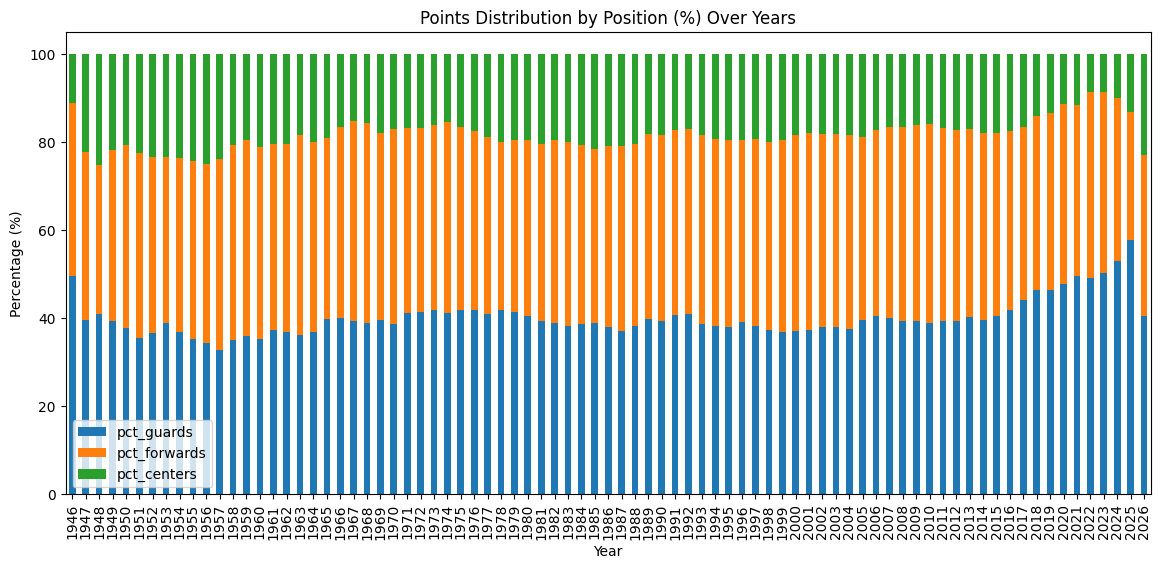

In [14]:
test4_pct = test4.copy()
test4_pct['total_points'] = test4_pct['points_guards'] + test4_pct['points_forwards'] + test4_pct['points_centers']
test4_pct['pct_guards'] = (test4_pct['points_guards'] / test4_pct['total_points'] * 100).round(2)
test4_pct['pct_forwards'] = (test4_pct['points_forwards'] / test4_pct['total_points'] * 100).round(2)
test4_pct['pct_centers'] = (test4_pct['points_centers'] / test4_pct['total_points'] * 100).round(2)

test4_pct[['GameYear', 'pct_guards', 'pct_forwards', 'pct_centers']].set_index('GameYear').plot(
    kind='bar', 
    stacked=True, 
    figsize=(14, 6),
    title='Points Distribution by Position (%) Over Years',
    ylabel='Percentage (%)',
    xlabel='Year'
)

### percentage of points from 3 pointers

In [5]:
test5 = pd.read_sql_query('''
with part1 as(
select
    year(gameDateTimeEst) as GameYear,
    sum(points) as total_points,
    SUM(freeThrowsMade) AS points_1pt,
    SUM(fieldGoalsMade - threePointersMade) * 2 AS points_2pt,
    SUM(threePointersMade) * 3 AS points_3pt
from PlayerStat
where gameDateTimeEst is not null
group by GameYear
order by GameYear
)
select *,
points_1pt / nullif(total_points, 0) * 100 as pct_1pt,
points_2pt / nullif(total_points, 0) * 100 as pct_2pt,
points_3pt / nullif(total_points, 0) * 100 as pct_3pt
from part1
''', conn)

C:\Users\Mark Rozenberg\AppData\Local\Temp\ipykernel_12656\967735790.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  test5 = pd.read_sql_query('''


<Axes: title={'center': 'Points by Shot Type Over Years'}, xlabel='Year', ylabel='Total Points'>

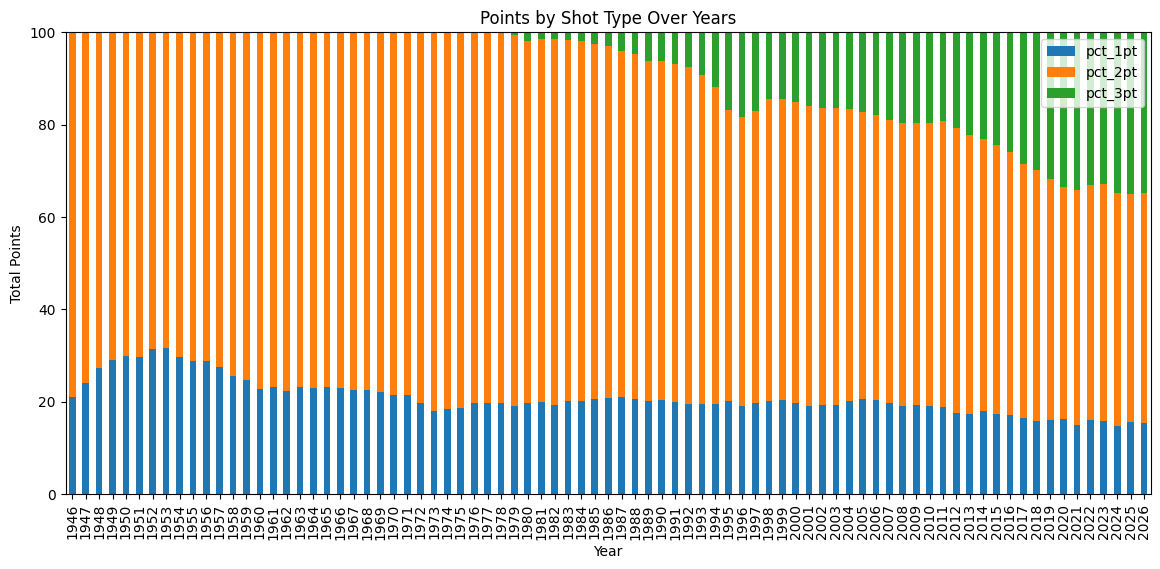

In [6]:
test5.set_index("GameYear")[["pct_1pt", "pct_2pt", "pct_3pt"]].plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6),
    title="Points by Shot Type Over Years",
    xlabel="Year",
    ylabel="Total Points"
)

### does the success percent of 3 pointers improved over years?

In [ ]:
test7 = pd.read_sql_query('''
with part1 as (
select
    year(gameDateTimeEst) as GameYear,
    sum(threePointersMade) as total_3pt_made,
    sum(threePointersAttempted) as total_3pt_attempted
from PlayerStat
where year(gameDateTimeEst) >= 1979 and gameDateTimeEst is not null
group by 1
)
select *,
total_3pt_made / nullif(total_3pt_attempted, 0) * 100 as pct_3pt_made
from part1
''', conn)

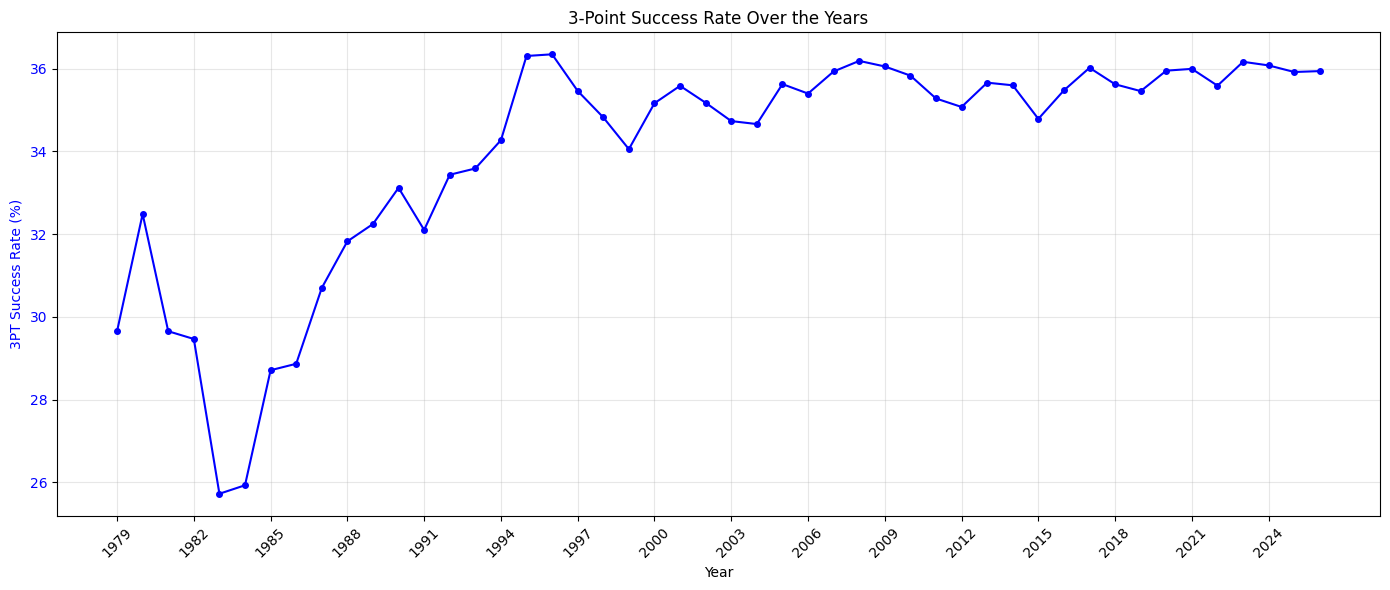

In [ ]:

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(test7['GameYear'], test7['pct_3pt_made'], color='blue', marker='o', markersize=4, label='3PT%')
ax1.set_xlabel('Year')
ax1.set_ylabel('3PT Success Rate (%)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('3-Point Success Rate Over the Years')
ax1.grid(True, alpha=0.3)

plt.xticks(test7['GameYear'][::3], rotation=45)
plt.tight_layout()
plt.show()

In [4]:
print(pd.read_sql_query('''select * from players limit 5''', conn).columns)
print(pd.read_sql_query('''select * from games limit 5''', conn).columns)
print(pd.read_sql_query('''select * from PlayerStat limit 5''', conn).columns)

Index(['personId', 'firstName', 'lastName', 'birthDate', 'school', 'country',
       'heightInches', 'bodyWeightLbs', 'guard', 'forward', 'center',
       'draftYear', 'draftRound', 'draftNumber'],
      dtype='str')
Index(['gameId', 'gameDateTimeEst', 'hometeamCity', 'hometeamName',
       'hometeamId', 'awayteamCity', 'awayteamName', 'awayteamId', 'homeScore',
       'awayScore', 'winner', 'gameType', 'gameSubtype', 'gameLabel',
       'gameSubLabel', 'seriesGameNumber', 'attendance', 'arenaId',
       'arenaName', 'arenaCity', 'arenaState', 'officials'],
      dtype='str')
Index(['firstName', 'lastName', 'personId', 'gameId', 'gameDateTimeEst',
       'playerteamCity', 'playerteamName', 'opponentteamCity',
       'opponentteamName', 'gameType', 'gameLabel', 'gameSubLabel',
       'seriesGameNumber', 'win', 'home', 'numMinutes', 'points', 'assists',
       'blocks', 'steals', 'fieldGoalsAttempted', 'fieldGoalsMade',
       'fieldGoalsPercentage', 'threePointersAttempted', 'threePoint

C:\Users\Mark Rozenberg\AppData\Local\Temp\ipykernel_21560\642650116.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql_query('''select * from players limit 5''', conn).columns)
C:\Users\Mark Rozenberg\AppData\Local\Temp\ipykernel_21560\642650116.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql_query('''select * from games limit 5''', conn).columns)
C:\Users\Mark Rozenberg\AppData\Local\Temp\ipykernel_21560\642650116.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sq

### 3 pointers attempts by player position over the years

C:\Users\Mark Rozenberg\AppData\Local\Temp\ipykernel_21560\1873561847.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  test8 = pd.read_sql_query('''


<Axes: title={'center': 'Average 3-Point Attempts per Minute by Position Over Years'}, xlabel='Year', ylabel='Average 3PT Attempts per Minute'>

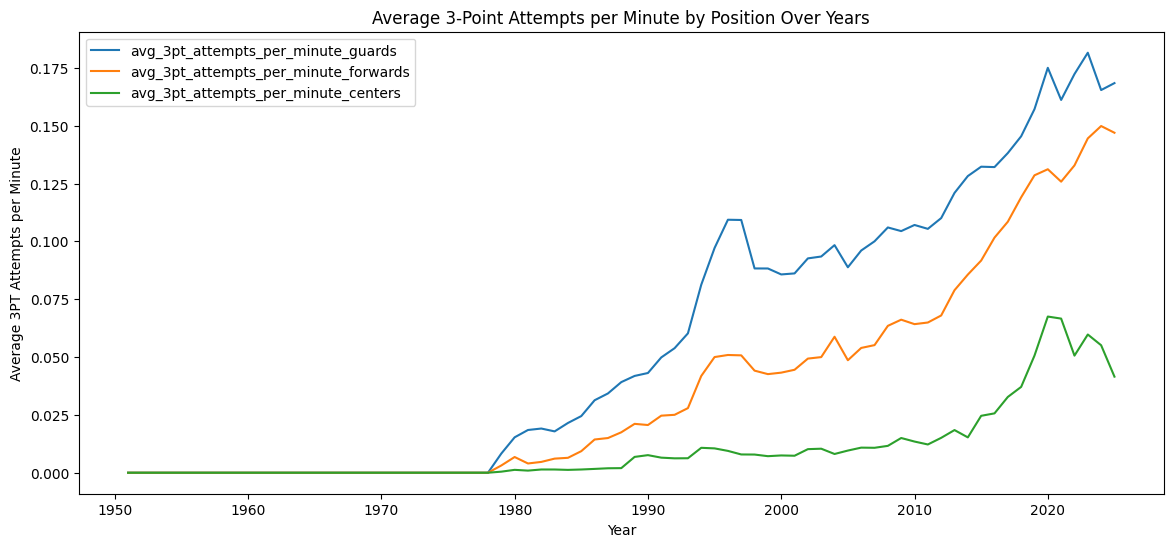

In [6]:
test8 = pd.read_sql_query('''
with part1 as (
    select
        personId,
        year(gameDateTimeEst) as GameYear,
        sum(threePointersAttempted) as total_3pt_attempted,
        sum(numMinutes) as total_minutes
    from PlayerStat
    where gameDateTimeEst is not null and year(gameDateTimeEst) < 2026
    group by 1, 2
),
part2 as (
select t1.*, t2.guard, t2.forward, t2.center,
total_3pt_attempted / nullif(total_minutes, 0) as three_pt_attempts_per_minute
from part1 t1
left join
players t2
on t1.personId = t2.personId
where total_minutes > 0
)
select GameYear,
avg(case when guard = 1 then three_pt_attempts_per_minute end) as avg_3pt_attempts_per_minute_guards,
avg(case when forward = 1 then three_pt_attempts_per_minute end) as avg_3pt_attempts_per_minute_forwards,
avg(case when center = 1 then three_pt_attempts_per_minute end) as avg_3pt_attempts_per_minute_centers
from part2
group by 1
order by 1
''', conn)
test8.set_index("GameYear")[["avg_3pt_attempts_per_minute_guards", "avg_3pt_attempts_per_minute_forwards", "avg_3pt_attempts_per_minute_centers"]].plot(
    kind="line",
    figsize=(14, 6),
    title="Average 3-Point Attempts per Minute by Position Over Years",
    xlabel="Year",
    ylabel="Average 3PT Attempts per Minute"
)

### Blocks per game over the years

C:\Users\Mark Rozenberg\AppData\Local\Temp\ipykernel_21560\3785748358.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  test9 = pd.read_sql_query('''


<Axes: title={'center': 'Average Blocks per Game Over Years'}, xlabel='Year', ylabel='Average Blocks per Game'>

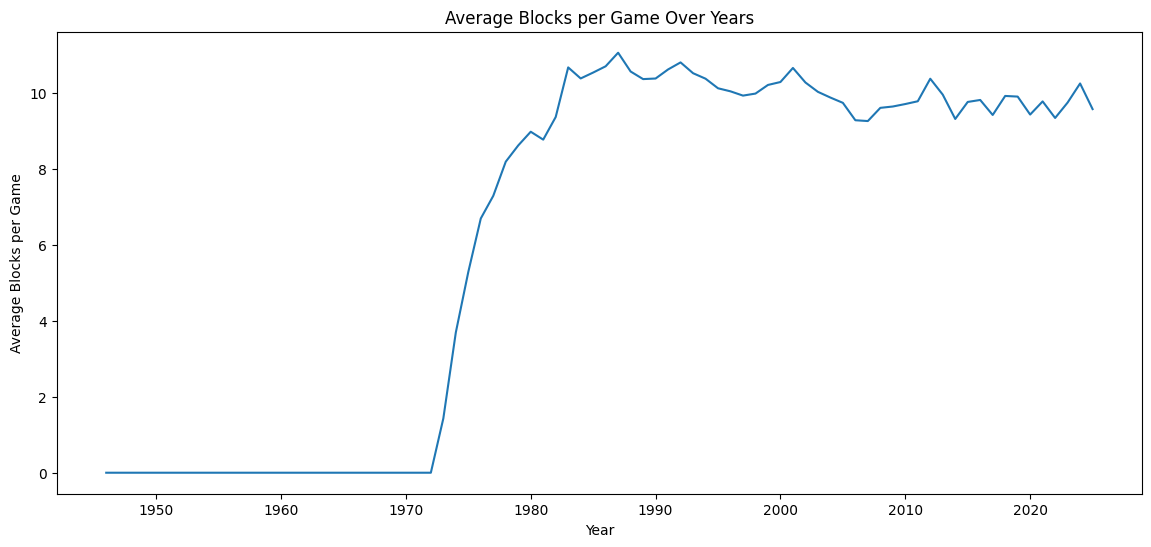

In [7]:
test9 = pd.read_sql_query('''
with part1 as (
    select
        GameId,
        year(gameDateTimeEst) as GameYear,
        sum(blocks) as total_blocks
    from PlayerStat
    where gameDateTimeEst is not null and year(gameDateTimeEst) < 2026
    group by 1, 2
)
select GameYear,
avg(total_blocks) as avg_blocks_per_game
from part1
group by 1
order by 1
''', conn)
test9.set_index("GameYear")["avg_blocks_per_game"].plot(
    kind="line",
    figsize=(14, 6),
    title="Average Blocks per Game Over Years",
    xlabel="Year",
    ylabel="Average Blocks per Game"
)

### average height of players by position over the years, only players played (positive number of minutes)

C:\Users\Mark Rozenberg\AppData\Local\Temp\ipykernel_21560\2558505799.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  test10 = pd.read_sql_query('''


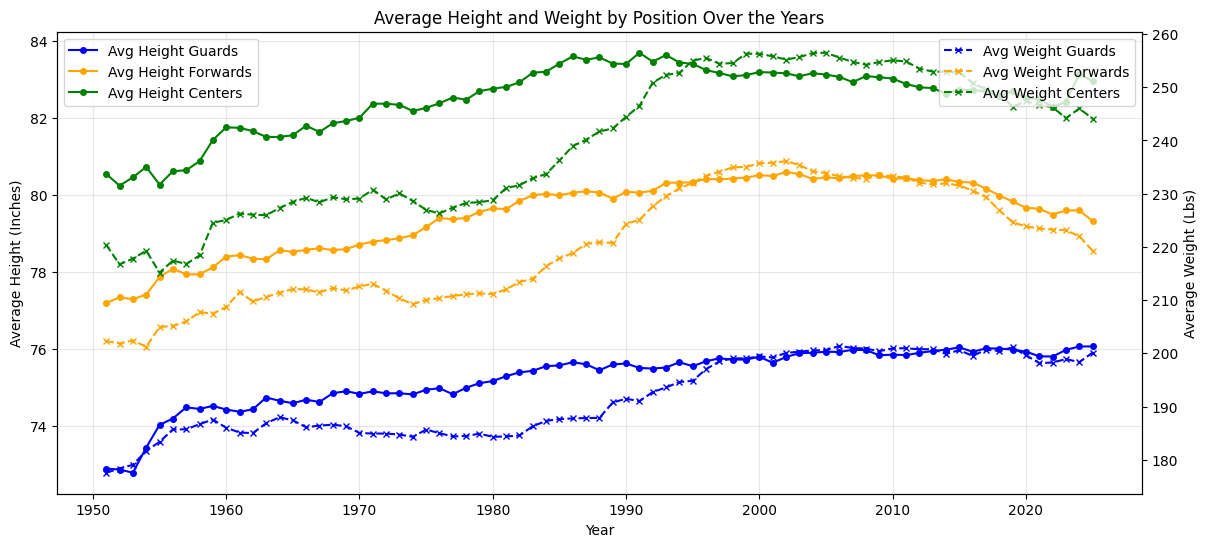

In [14]:
test10 = pd.read_sql_query('''
with part1 as (
    select
        personId,
        year(gameDateTimeEst) as GameYear
from PlayerStat
where gameDateTimeEst is not null and year(gameDateTimeEst) < 2026 and numMinutes > 0
group by 1, 2
),
part2 as (
select t1.GameYear, t2.heightInches, t2.bodyWeightLbs, t2.guard, t2.forward, t2.center
from part1 as t1
left join
Players as t2
on t1.personId = t2.personId
order by 1
)
select GameYear,
avg(case when guard = 1 then heightInches end) as avg_height_guards,
avg(case when forward = 1 then heightInches end) as avg_height_forwards,
avg(case when center = 1 then heightInches end) as avg_height_centers,
avg(case when guard = 1 then bodyWeightLbs end) as avg_weight_guards,
avg(case when forward = 1 then bodyWeightLbs end) as avg_weight_forwards,
avg(case when center = 1 then bodyWeightLbs end) as avg_weight_centers
from part2
group by 1
order by 1
''', conn)
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(test10['GameYear'], test10['avg_height_guards'], color='blue', marker='o', markersize=4, label='Avg Height Guards')
ax1.plot(test10['GameYear'], test10['avg_height_forwards'], color='orange', marker='o', markersize=4, label='Avg Height Forwards')
ax1.plot(test10['GameYear'], test10['avg_height_centers'], color='green', marker='o', markersize=4, label='Avg Height Centers')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Height (Inches)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_title('Average Height and Weight by Position Over the Years')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.plot(test10['GameYear'], test10['avg_weight_guards'], color='blue', marker='x', markersize=4, linestyle='--', label='Avg Weight Guards')
ax2.plot(test10['GameYear'], test10['avg_weight_forwards'], color='orange', marker='x', markersize=4, linestyle='--', label='Avg Weight Forwards')
ax2.plot(test10['GameYear'], test10['avg_weight_centers'], color='green', marker='x', markersize=4, linestyle='--', label='Avg Weight Centers')
ax2.set_ylabel('Average Weight (Lbs)', color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.legend(loc='upper right')